# Agricultural Data Analysis for Gramin Saathi

This notebook analyzes three agricultural datasets to extract insights for crop yield prediction and price forecasting. The goal is to generate usable data and interactive visualizations for web integration.

## 1. Import Required Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load and Explore the Three CSV Files

In [2]:
# Load all three datasets
df_prices = pd.read_csv('Agriculture_price_dataset.csv')
df_icrisat = pd.read_csv('ICRISAT-District Level Data.csv')
df_yield = pd.read_csv('crop_yield.csv')

print("=" * 80)
print("📊 DATASET 1: Agriculture Prices")
print("=" * 80)
print(f"Shape: {df_prices.shape}")
print(f"Columns: {df_prices.columns.tolist()}")
print("\nFirst few rows:")
display(df_prices.head())
print("\nData types:")
print(df_prices.dtypes)
print("\nMissing values:")
print(df_prices.isnull().sum())

print("\n" + "=" * 80)
print("📊 DATASET 2: ICRISAT District Level Data")
print("=" * 80)
print(f"Shape: {df_icrisat.shape}")
print(f"Columns: {df_icrisat.columns.tolist()}")
print("\nFirst few rows:")
display(df_icrisat.head())
print("\nData types:")
print(df_icrisat.dtypes)
print("\nMissing values:")
print(df_icrisat.isnull().sum())

print("\n" + "=" * 80)
print("📊 DATASET 3: Crop Yield")
print("=" * 80)
print(f"Shape: {df_yield.shape}")
print(f"Columns: {df_yield.columns.tolist()}")
print("\nFirst few rows:")
display(df_yield.head())
print("\nData types:")
print(df_yield.dtypes)
print("\nMissing values:")
print(df_yield.isnull().sum())

📊 DATASET 1: Agriculture Prices
Shape: (737392, 10)
Columns: ['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade', 'Min_Price', 'Max_Price', 'Modal_Price', 'Price Date']

First few rows:


,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6/6/2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6/6/2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6/6/2023
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,6/6/2023
4,Rajasthan,pratapgarh,Pratapgarh,Onion,Other,FAQ,476.0,1043.0,617.0,6/6/2023



Data types:
STATE             object
District Name     object
Market Name       object
Commodity         object
Variety           object
Grade             object
Min_Price        float64
Max_Price        float64
Modal_Price      float64
Price Date        object
dtype: object

Missing values:
STATE            0
District Name    0
Market Name      0
Commodity        0
Variety          0
Grade            0
Min_Price        0
Max_Price        0
Modal_Price      0
Price Date       0
dtype: int64

📊 DATASET 2: ICRISAT District Level Data
Shape: (16146, 80)
Columns: ['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'RICE AREA (1000 ha)', 'RICE PRODUCTION (1000 tons)', 'RICE YIELD (Kg per ha)', 'WHEAT AREA (1000 ha)', 'WHEAT PRODUCTION (1000 tons)', 'WHEAT YIELD (Kg per ha)', 'KHARIF SORGHUM AREA (1000 ha)', 'KHARIF SORGHUM PRODUCTION (1000 tons)', 'KHARIF SORGHUM YIELD (Kg per ha)', 'RABI SORGHUM AREA (1000 ha)', 'RABI SORGHUM PRODUCTION (1000 tons)', 'RABI SORGHUM YIELD (Kg per

,Dist Code,Year,State Code,State Name,Dist Name,RICE AREA (1000 ha),RICE PRODUCTION (1000 tons),RICE YIELD (Kg per ha),WHEAT AREA (1000 ha),WHEAT PRODUCTION (1000 tons),WHEAT YIELD (Kg per ha),KHARIF SORGHUM AREA (1000 ha),KHARIF SORGHUM PRODUCTION (1000 tons),KHARIF SORGHUM YIELD (Kg per ha),RABI SORGHUM AREA (1000 ha),RABI SORGHUM PRODUCTION (1000 tons),RABI SORGHUM YIELD (Kg per ha),SORGHUM AREA (1000 ha),SORGHUM PRODUCTION (1000 tons),SORGHUM YIELD (Kg per ha),PEARL MILLET AREA (1000 ha),PEARL MILLET PRODUCTION (1000 tons),PEARL MILLET YIELD (Kg per ha),MAIZE AREA (1000 ha),MAIZE PRODUCTION (1000 tons),MAIZE YIELD (Kg per ha),FINGER MILLET AREA (1000 ha),FINGER MILLET PRODUCTION (1000 tons),FINGER MILLET YIELD (Kg per ha),BARLEY AREA (1000 ha),BARLEY PRODUCTION (1000 tons),BARLEY YIELD (Kg per ha),CHICKPEA AREA (1000 ha),CHICKPEA PRODUCTION (1000 tons),CHICKPEA YIELD (Kg per ha),PIGEONPEA AREA (1000 ha),PIGEONPEA PRODUCTION (1000 tons),PIGEONPEA YIELD (Kg per ha),MINOR PULSES AREA (1000 ha),MINOR PULSES PRODUCTION (1000 tons),MINOR PULSES YIELD (Kg per ha),GROUNDNUT AREA (1000 ha),GROUNDNUT PRODUCTION (1000 tons),GROUNDNUT YIELD (Kg per ha),SESAMUM AREA (1000 ha),SESAMUM PRODUCTION (1000 tons),SESAMUM YIELD (Kg per ha),RAPESEED AND MUSTARD AREA (1000 ha),RAPESEED AND MUSTARD PRODUCTION (1000 tons),RAPESEED AND MUSTARD YIELD (Kg per ha),SAFFLOWER AREA (1000 ha),SAFFLOWER PRODUCTION (1000 tons),SAFFLOWER YIELD (Kg per ha),CASTOR AREA (1000 ha),CASTOR PRODUCTION (1000 tons),CASTOR YIELD (Kg per ha),LINSEED AREA (1000 ha),LINSEED PRODUCTION (1000 tons),LINSEED YIELD (Kg per ha),SUNFLOWER AREA (1000 ha),SUNFLOWER PRODUCTION (1000 tons),SUNFLOWER YIELD (Kg per ha),SOYABEAN AREA (1000 ha),SOYABEAN PRODUCTION (1000 tons),SOYABEAN YIELD (Kg per ha),OILSEEDS AREA (1000 ha),OILSEEDS PRODUCTION (1000 tons),OILSEEDS YIELD (Kg per ha),SUGARCANE AREA (1000 ha),SUGARCANE PRODUCTION (1000 tons),SUGARCANE YIELD (Kg per ha),COTTON AREA (1000 ha),COTTON PRODUCTION (1000 tons),COTTON YIELD (Kg per ha),FRUITS AREA (1000 ha),VEGETABLES AREA (1000 ha),FRUITS AND VEGETABLES AREA (1000 ha),POTATOES AREA (1000 ha),ONION AREA (1000 ha),FODDER AREA (1000 ha)
0,1,1966,14,Chhattisgarh,Durg,548.0,185.0,337.59,44.0,20.0,454.55,0.6,0.4,666.67,0.0,0.0,0.0,0.6,0.4,666.67,0.0,0.0,0.0,3.0,2.0,666.67,0.8,0.2,250.00,0.1,0.0,0.0,54.0,27.0,500.00,37.0,15.0,405.41,114.96,-1.0,-1.00,0.2,0.1,500.0,3.0,0.3,100.00,1.0,0.2,200.00,0.07,0.0,0.0,0.7,0.2,285.71,45.7,6.8,148.80,0.0,0.0,0.0,0.0,0.0,0.0,50.70,-1.0,-1.00,0.9,1.6,1777.78,0.0,0.0,0.0,5.95,6.64,12.59,0.01,0.60,0.47
1,1,1967,14,Chhattisgarh,Durg,547.0,409.0,747.71,50.0,26.0,520.00,1.1,0.9,818.18,0.0,0.0,0.0,1.1,0.9,818.18,0.0,0.0,0.0,3.0,3.0,1000.00,0.9,0.2,222.22,0.2,0.1,500.0,52.0,15.0,288.46,36.0,26.0,722.22,269.54,-1.0,-1.00,0.1,0.1,1000.0,11.6,0.9,77.59,1.1,0.3,272.73,0.01,0.0,0.0,0.5,0.1,200.00,100.1,25.8,257.74,0.0,0.0,0.0,0.0,0.0,0.0,113.55,-1.0,-1.00,0.8,1.2,1500.00,0.0,0.0,0.0,5.77,7.24,13.02,0.01,0.56,1.23
2,1,1968,14,Chhattisgarh,Durg,556.3,468.0,841.27,53.7,30.0,558.66,0.5,0.4,800.00,0.0,0.0,0.0,0.5,0.4,800.00,0.0,0.0,0.0,2.8,2.0,714.29,0.8,0.2,250.00,0.2,0.1,500.0,51.3,23.0,448.34,35.7,28.0,784.31,289.46,-1.0,-1.00,0.1,0.1,1000.0,11.3,1.6,141.59,1.2,0.5,416.67,0.02,0.0,0.0,0.6,0.3,500.00,113.3,23.8,210.06,0.0,0.0,0.0,0.0,0.0,0.0,126.62,-1.0,-1.00,1.0,1.0,1000.00,0.0,0.0,0.0,5.41,7.40,12.81,0.10,0.58,1.02
3,1,1969,14,Chhattisgarh,Durg,563.4,400.8,711.40,49.4,26.5,536.44,0.8,0.6,750.00,0.0,0.0,0.0,0.8,0.6,750.00,0.0,0.0,0.0,2.7,2.3,851.85,0.8,0.2,250.00,0.2,0.1,500.0,52.6,23.1,439.16,35.7,27.3,764.71,298.18,98.3,329.67,0.1,0.1,1000.0,11.4,1.4,122.81,1.2,0.4,333.33,0.02,0.0,0.0,0.5,0.1,200.00,101.1,13.0,128.59,0.0,0.0,0.0,0.0,0.0,0.0,114.14,14.9,130.54,1.0,1.9,1900.00,0.0,0.0,0.0,5.52,7.16,12.69,0.01,0.56,0.84
4,1,1970,14,Chhattisgarh,Durg,571.6,473.6,828.55,44.2,29.0,656.11,0.9,0.6,666.67,0.0,0.0,0.0,0.9,0.6,666.67,0.0,0.0,0.0,2.5,3.3,1320.00,0.8,0.2,250.00,0.1,0.1,1000.0,53.3,32.6,611.63,33.3,35.2,1057


Data types:
Dist Code                                        int64
Year                                             int64
State Code                                       int64
State Name                                      object
Dist Name                                       object
RICE AREA (1000 ha)                            float64
RICE PRODUCTION (1000 tons)                    float64
RICE YIELD (Kg per ha)                         float64
WHEAT AREA (1000 ha)                           float64
WHEAT PRODUCTION (1000 tons)                   float64
WHEAT YIELD (Kg per ha)                        float64
KHARIF SORGHUM AREA (1000 ha)                  float64
KHARIF SORGHUM PRODUCTION (1000 tons)          float64
KHARIF SORGHUM YIELD (Kg per ha)               float64
RABI SORGHUM AREA (1000 ha)                    float64
RABI SORGHUM PRODUCTION (1000 tons)            float64
RABI SORGHUM YIELD (Kg per ha)                 float64
SORGHUM AREA (1000 ha)                         float

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909



Data types:
Crop                object
Crop_Year            int64
Season              object
State               object
Area               float64
Production           int64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
dtype: object

Missing values:
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64


## 3. Data Cleaning and Preprocessing

In [3]:
# Clean Dataset 1: Agriculture Prices
print("🧹 Cleaning Agriculture Prices Dataset...")
df_prices_clean = df_prices.copy()
# Remove duplicates
df_prices_clean = df_prices_clean.drop_duplicates()
# Handle missing values (strategy will depend on the data)
missing_threshold = 0.5
for col in df_prices_clean.columns:
    missing_pct = df_prices_clean[col].isnull().sum() / len(df_prices_clean)
    if missing_pct > missing_threshold:
        print(f"Dropping column '{col}' with {missing_pct*100:.1f}% missing values")
        df_prices_clean = df_prices_clean.drop(columns=[col])
# Fill remaining missing values appropriately
for col in df_prices_clean.select_dtypes(include=[np.number]).columns:
    df_prices_clean[col].fillna(df_prices_clean[col].median(), inplace=True)
for col in df_prices_clean.select_dtypes(include=['object']).columns:
    df_prices_clean[col].fillna(df_prices_clean[col].mode()[0] if not df_prices_clean[col].mode().empty else 'Unknown', inplace=True)

print(f"✅ Cleaned shape: {df_prices_clean.shape}")

# Clean Dataset 2: ICRISAT
print("\n🧹 Cleaning ICRISAT Dataset...")
df_icrisat_clean = df_icrisat.copy()
df_icrisat_clean = df_icrisat_clean.drop_duplicates()
for col in df_icrisat_clean.columns:
    missing_pct = df_icrisat_clean[col].isnull().sum() / len(df_icrisat_clean)
    if missing_pct > missing_threshold:
        print(f"Dropping column '{col}' with {missing_pct*100:.1f}% missing values")
        df_icrisat_clean = df_icrisat_clean.drop(columns=[col])
for col in df_icrisat_clean.select_dtypes(include=[np.number]).columns:
    df_icrisat_clean[col].fillna(df_icrisat_clean[col].median(), inplace=True)
for col in df_icrisat_clean.select_dtypes(include=['object']).columns:
    df_icrisat_clean[col].fillna(df_icrisat_clean[col].mode()[0] if not df_icrisat_clean[col].mode().empty else 'Unknown', inplace=True)

print(f"✅ Cleaned shape: {df_icrisat_clean.shape}")

# Clean Dataset 3: Crop Yield
print("\n🧹 Cleaning Crop Yield Dataset...")
df_yield_clean = df_yield.copy()
df_yield_clean = df_yield_clean.drop_duplicates()
for col in df_yield_clean.columns:
    missing_pct = df_yield_clean[col].isnull().sum() / len(df_yield_clean)
    if missing_pct > missing_threshold:
        print(f"Dropping column '{col}' with {missing_pct*100:.1f}% missing values")
        df_yield_clean = df_yield_clean.drop(columns=[col])
for col in df_yield_clean.select_dtypes(include=[np.number]).columns:
    df_yield_clean[col].fillna(df_yield_clean[col].median(), inplace=True)
for col in df_yield_clean.select_dtypes(include=['object']).columns:
    df_yield_clean[col].fillna(df_yield_clean[col].mode()[0] if not df_yield_clean[col].mode().empty else 'Unknown', inplace=True)

print(f"✅ Cleaned shape: {df_yield_clean.shape}")

print("\n✅ All datasets cleaned successfully!")

🧹 Cleaning Agriculture Prices Dataset...
✅ Cleaned shape: (737392, 10)

🧹 Cleaning ICRISAT Dataset...
✅ Cleaned shape: (16146, 80)

🧹 Cleaning Crop Yield Dataset...
✅ Cleaned shape: (19689, 10)

✅ All datasets cleaned successfully!


## 4. Exploratory Data Analysis (EDA) with Visualizations

In [4]:
# Statistical Summary
print("📈 STATISTICAL SUMMARY")
print("=" * 80)
print("\nDataset 1: Agriculture Prices")
display(df_prices_clean.describe())

print("\nDataset 2: ICRISAT")
display(df_icrisat_clean.describe())

print("\nDataset 3: Crop Yield")
display(df_yield_clean.describe())

📈 STATISTICAL SUMMARY

Dataset 1: Agriculture Prices


,Min_Price,Max_Price,Modal_Price
count,737392.000000,737392.000000,737392.000000
mean,2204.849862,2659.733824,2474.484638
std,1920.977696,2145.250773,2023.851909
min,0.000000,0.000000,0.000000
25%,1100.000000,1500.000000,1300.000000
50%,2000.000000,2300.000000,2150.000000
75%,2700.000000,3205.000000,3000.000000
max,420000.000000,480000.000000,460000.000000



Dataset 2: ICRISAT


,Dist Code,Year,State Code,RICE AREA (1000 ha),RICE PRODUCTION (1000 tons),RICE YIELD (Kg per ha),WHEAT AREA (1000 ha),WHEAT PRODUCTION (1000 tons),WHEAT YIELD (Kg per ha),KHARIF SORGHUM AREA (1000 ha),KHARIF SORGHUM PRODUCTION (1000 tons),KHARIF SORGHUM YIELD (Kg per ha),RABI SORGHUM AREA (1000 ha),RABI SORGHUM PRODUCTION (1000 tons),RABI SORGHUM YIELD (Kg per ha),SORGHUM AREA (1000 ha),SORGHUM PRODUCTION (1000 tons),SORGHUM YIELD (Kg per ha),PEARL MILLET AREA (1000 ha),PEARL MILLET PRODUCTION (1000 tons),PEARL MILLET YIELD (Kg per ha),MAIZE AREA (1000 ha),MAIZE PRODUCTION (1000 tons),MAIZE YIELD (Kg per ha),FINGER MILLET AREA (1000 ha),FINGER MILLET PRODUCTION (1000 tons),FINGER MILLET YIELD (Kg per ha),BARLEY AREA (1000 ha),BARLEY PRODUCTION (1000 tons),BARLEY YIELD (Kg per ha),CHICKPEA AREA (1000 ha),CHICKPEA PRODUCTION (1000 tons),CHICKPEA YIELD (Kg per ha),PIGEONPEA AREA (1000 ha),PIGEONPEA PRODUCTION (1000 tons),PIGEONPEA YIELD (Kg per ha),MINOR PULSES AREA (1000 ha),MINOR PULSES PRODUCTION (1000 tons),MINOR PULSES YIELD (Kg per ha),GROUNDNUT AREA (1000 ha),GROUNDNUT PRODUCTION (1000 tons),GROUNDNUT YIELD (Kg per ha),SESAMUM AREA (1000 ha),SESAMUM PRODUCTION (1000 tons),SESAMUM YIELD (Kg per ha),RAPESEED AND MUSTARD AREA (1000 ha),RAPESEED AND MUSTARD PRODUCTION (1000 tons),RAPESEED AND MUSTARD YIELD (Kg per ha),SAFFLOWER AREA (1000 ha),SAFFLOWER PRODUCTION (1000 tons),SAFFLOWER YIELD (Kg per ha),CASTOR AREA (1000 ha),CASTOR PRODUCTION (1000 tons),CASTOR YIELD (Kg per ha),LINSEED AREA (1000 ha),LINSEED PRODUCTION (1000 tons),LINSEED YIELD (Kg per ha),SUNFLOWER AREA (1000 ha),SUNFLOWER PRODUCTION (1000 tons),SUNFLOWER YIELD (Kg per ha),SOYABEAN AREA (1000 ha),SOYABEAN PRODUCTION (1000 tons),SOYABEAN YIELD (Kg per ha),OILSEEDS AREA (1000 ha),OILSEEDS PRODUCTION (1000 tons),OILSEEDS YIELD (Kg per ha),SUGARCANE AREA (1000 ha),SUGARCANE PRODUCTION (1000 tons),SUGARCANE YIELD (Kg per ha),COTTON AREA (1000 ha),COTTON PRODUCTION (1000 tons),COTTON YIELD (Kg per ha),FRUITS AREA (1000 ha),VEGETABLES AREA (1000 ha),FRUITS AND VEGETABLES AREA (1000 ha),POTATOES AREA (1000 ha),ONION AREA (1000 ha),FODDER AREA (1000 ha)
count,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.00000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.00000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000
mean,269.769231,1991.496841,9.568562,128.593192,224.889565,1486.924784,77.057946,182.012746,1492.419859,22.632268,18.358094,586.031073,17.386122,10.003391,225.635763,40.150105,28.461353,586.093561,33.195694,22.125087,517.917093,20.12212,36.053213,1408.763218,6.247760,7.110997,354.849116,4.171439,5.882636,734.246365,23.866339,18.046505,630.818187,10.480133,7.436633,618.020169,41.461086,16.665397,453.632634,22.439889,22.030686,765.947652,6.104558,1.870781,264.729010,12.968989,12.400292,497.953629,1.760133,0.689239,73.048318,2.188699,2.209565,215.405711,2.448820,0.687567,175.548071,3.008939,1.591570,278.449695,13.668797,13.946461,242.960655,66.740024,50.909822,593.659625,11.905851,75.511777,4500.15306,28.018367,7.229225,124.644823,7.750478,11.086250,18.677877,3.177038,1.194604,21.550328
std,278.309125,15.011185,4.988538,16


Dataset 3: Crop Yield


,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


📊 Creating visualizations for Agriculture Prices...


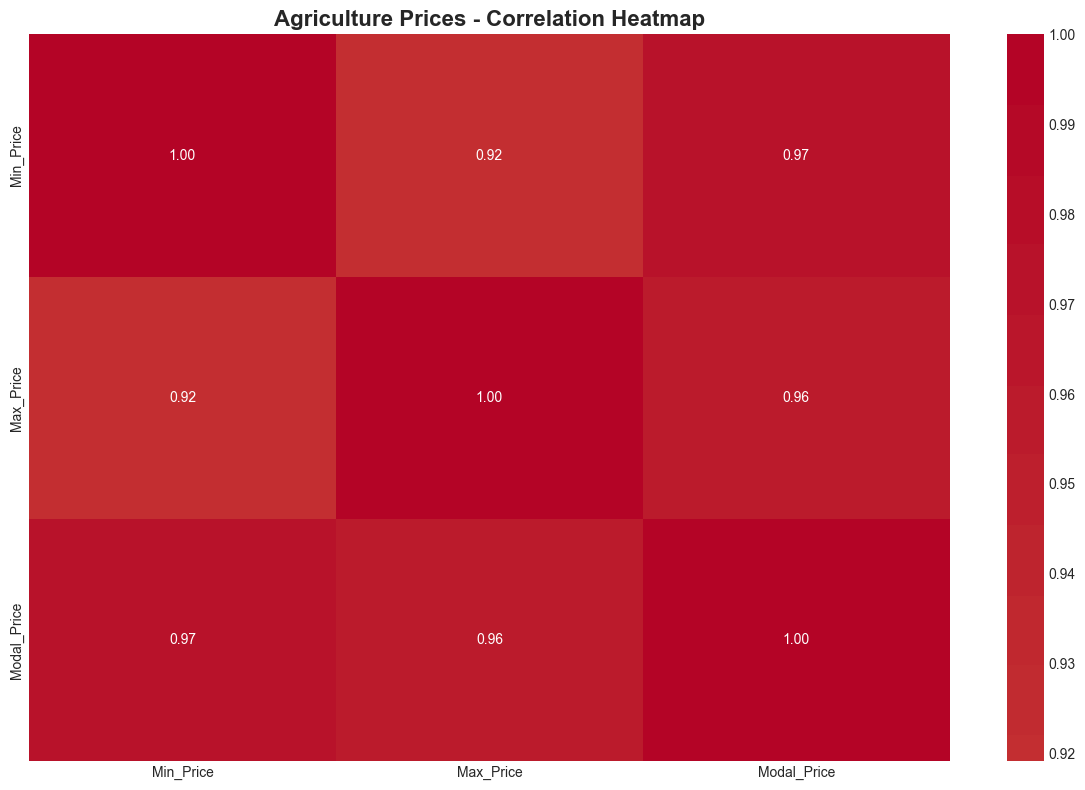

In [5]:
# Visualizations for Dataset 1: Agriculture Prices
print("📊 Creating visualizations for Agriculture Prices...")

# Select numeric columns for correlation
numeric_cols = df_prices_clean.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 1:
    # Correlation heatmap
    fig = plt.figure(figsize=(12, 8))
    correlation_matrix = df_prices_clean[numeric_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Agriculture Prices - Correlation Heatmap', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
# Distribution plots
if len(numeric_cols) >= 4:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    for idx, col in enumerate(numeric_cols[:4]):
        row, col_idx = idx // 2, idx % 2
        axes[row, col_idx].hist(df_prices_clean[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[row, col_idx].set_title(f'Distribution of {col}', fontweight='bold')
        axes[row, col_idx].set_xlabel(col)
        axes[row, col_idx].set_ylabel('Frequency')
    plt.suptitle('Agriculture Prices - Distribution Plots', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

📊 Creating visualizations for ICRISAT District Data...


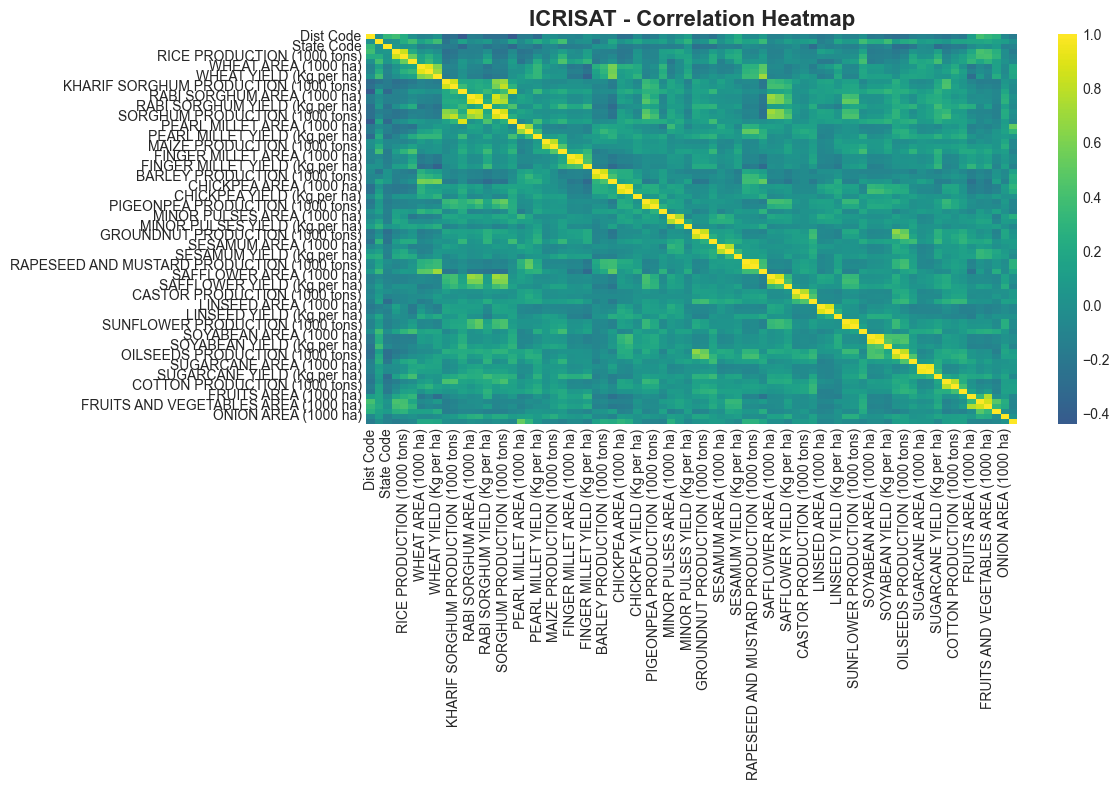

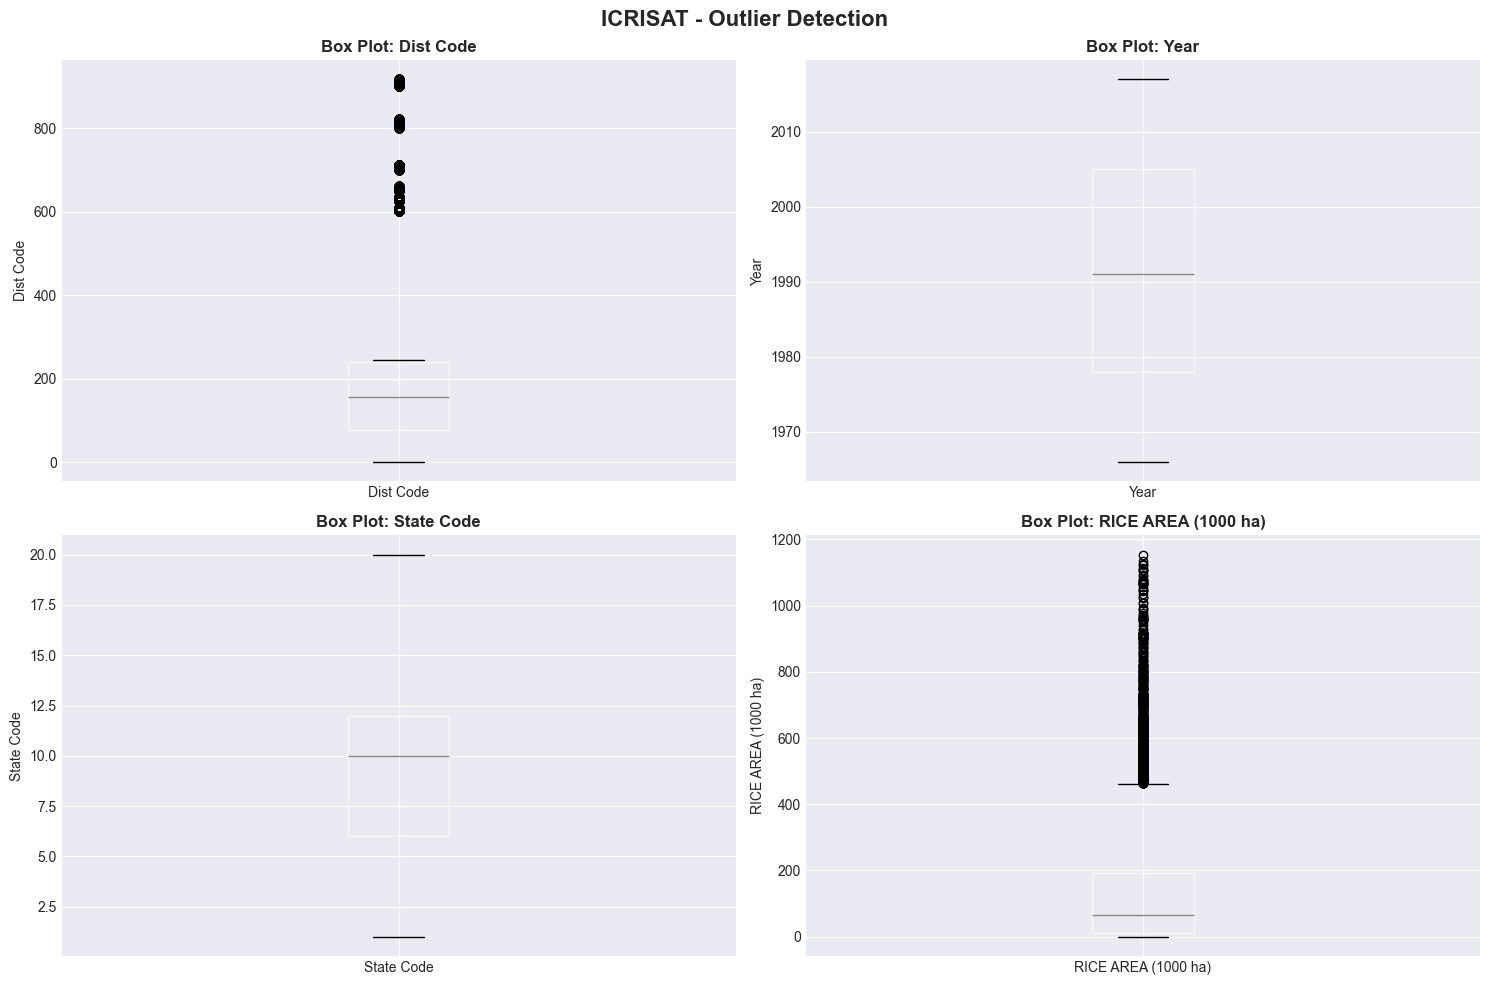

In [6]:
# Visualizations for Dataset 2: ICRISAT
print("📊 Creating visualizations for ICRISAT District Data...")

numeric_cols_ic = df_icrisat_clean.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols_ic) > 1:
    fig = plt.figure(figsize=(12, 8))
    correlation_matrix = df_icrisat_clean[numeric_cols_ic].corr()
    sns.heatmap(correlation_matrix, annot=True if len(numeric_cols_ic) <= 10 else False, 
                cmap='viridis', center=0, fmt='.2f')
    plt.title('ICRISAT - Correlation Heatmap', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Box plots for outlier detection
if len(numeric_cols_ic) >= 4:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    for idx, col in enumerate(numeric_cols_ic[:4]):
        row, col_idx = idx // 2, idx % 2
        df_icrisat_clean.boxplot(column=col, ax=axes[row, col_idx])
        axes[row, col_idx].set_title(f'Box Plot: {col}', fontweight='bold')
        axes[row, col_idx].set_ylabel(col)
    plt.suptitle('ICRISAT - Outlier Detection', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

📊 Creating visualizations for Crop Yield...


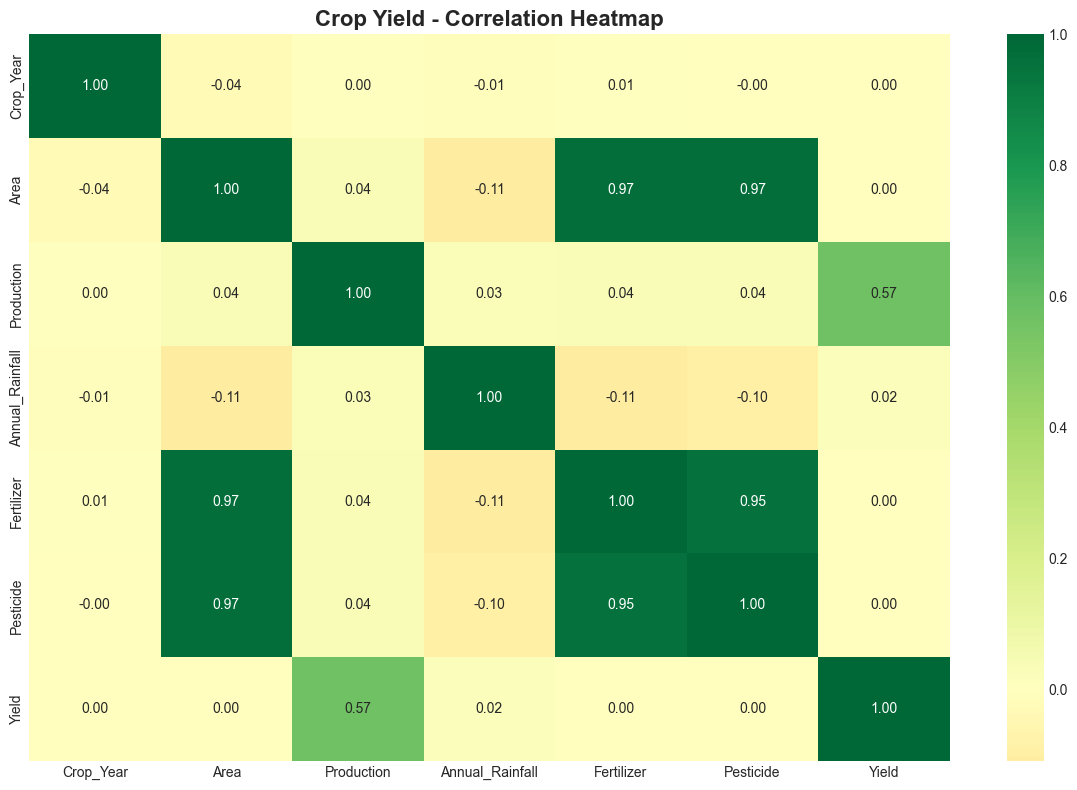

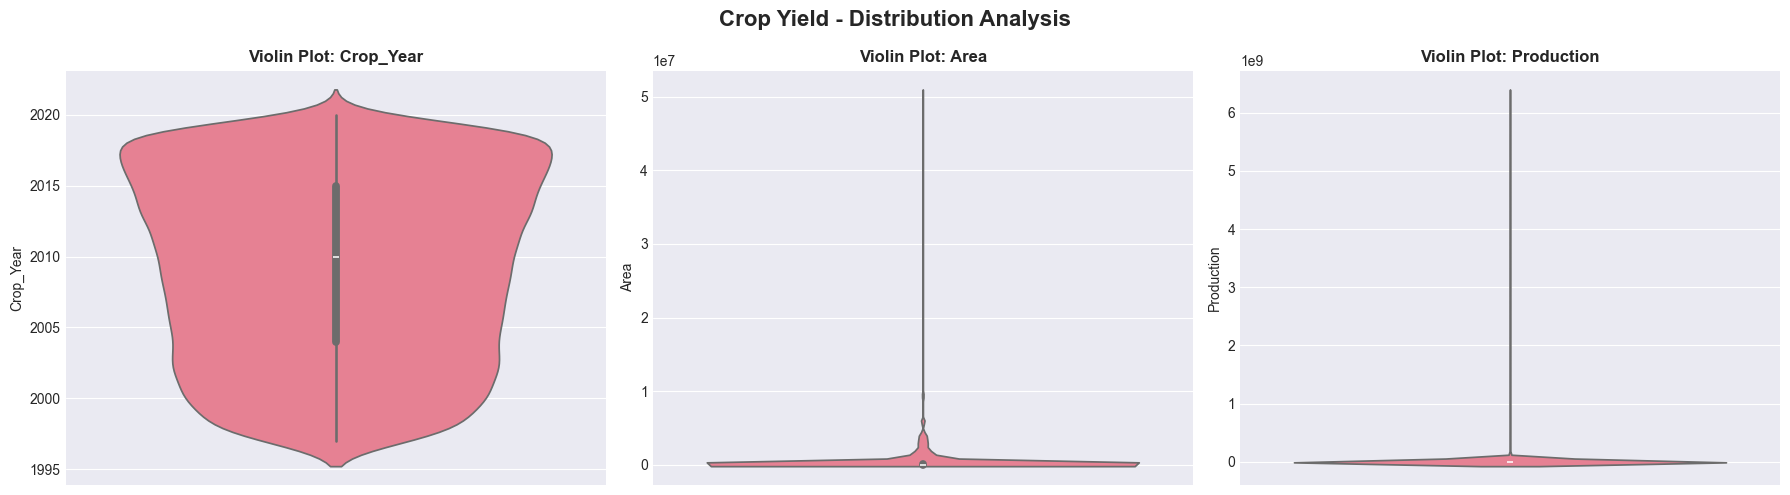

In [7]:
# Visualizations for Dataset 3: Crop Yield
print("📊 Creating visualizations for Crop Yield...")

numeric_cols_yield = df_yield_clean.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols_yield) > 1:
    fig = plt.figure(figsize=(12, 8))
    correlation_matrix = df_yield_clean[numeric_cols_yield].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f')
    plt.title('Crop Yield - Correlation Heatmap', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Violin plots
if len(numeric_cols_yield) >= 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for idx, col in enumerate(numeric_cols_yield[:3]):
        sns.violinplot(y=df_yield_clean[col], ax=axes[idx])
        axes[idx].set_title(f'Violin Plot: {col}', fontweight='bold')
        axes[idx].set_ylabel(col)
    plt.suptitle('Crop Yield - Distribution Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5. Interactive Plotly Charts for Web Integration

In [8]:
# Create output directory for charts
import os
output_dir = 'output_charts'
os.makedirs(output_dir, exist_ok=True)

print("🎨 Creating interactive Plotly charts for web integration...")
print(f"📁 Charts will be saved to: {output_dir}/")

# Chart 1: Interactive scatter plot (if we have appropriate columns)
try:
    # This is a template - adjust column names based on actual data
    numeric_cols = df_yield_clean.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) >= 2:
        fig = px.scatter(df_yield_clean, 
                        x=numeric_cols[0], 
                        y=numeric_cols[1],
                        title=f'Crop Yield: {numeric_cols[0]} vs {numeric_cols[1]}',
                        labels={numeric_cols[0]: numeric_cols[0].title(), 
                               numeric_cols[1]: numeric_cols[1].title()},
                        template='plotly_white')
        fig.update_traces(marker=dict(size=8, opacity=0.6))
        fig.write_html(f'{output_dir}/scatter_yield.html')
        fig.show()
        print(f"✅ Saved: scatter_yield.html")
except Exception as e:
    print(f"⚠️ Could not create scatter plot: {e}")

🎨 Creating interactive Plotly charts for web integration...
📁 Charts will be saved to: output_charts/
⚠️ Could not create scatter plot: Mime type rendering requires nbformat>=4.2.0 but it is not installed


In [9]:
# Chart 2: Bar chart for categorical analysis
try:
    # Find categorical columns
    cat_cols = df_prices_clean.select_dtypes(include=['object']).columns.tolist()
    if cat_cols:
        # Count top categories
        col = cat_cols[0]
        top_categories = df_prices_clean[col].value_counts().head(15)
        
        fig = px.bar(x=top_categories.index, 
                    y=top_categories.values,
                    title=f'Top 15 {col.title()} by Count',
                    labels={'x': col.title(), 'y': 'Count'},
                    template='plotly_white',
                    color=top_categories.values,
                    color_continuous_scale='viridis')
        fig.update_layout(showlegend=False, xaxis_tickangle=-45)
        fig.write_html(f'{output_dir}/bar_chart_{col}.html')
        fig.show()
        print(f"✅ Saved: bar_chart_{col}.html")
except Exception as e:
    print(f"⚠️ Could not create bar chart: {e}")

⚠️ Could not create bar chart: Mime type rendering requires nbformat>=4.2.0 but it is not installed


In [10]:
# Chart 3: Time series or line chart
try:
    # Check for date columns or year columns
    date_cols = [col for col in df_yield_clean.columns if 'year' in col.lower() or 'date' in col.lower()]
    numeric_cols = df_yield_clean.select_dtypes(include=[np.number]).columns.tolist()
    
    if date_cols and numeric_cols:
        date_col = date_cols[0]
        value_col = numeric_cols[0]
        
        # Aggregate by date/year
        grouped = df_yield_clean.groupby(date_col)[value_col].mean().reset_index()
        
        fig = px.line(grouped, 
                     x=date_col, 
                     y=value_col,
                     title=f'{value_col.title()} Trend Over Time',
                     labels={date_col: date_col.title(), value_col: value_col.title()},
                     template='plotly_white')
        fig.update_traces(line_color='#22c55e', line_width=3)
        fig.update_layout(hovermode='x unified')
        fig.write_html(f'{output_dir}/line_trend.html')
        fig.show()
        print(f"✅ Saved: line_trend.html")
except Exception as e:
    print(f"⚠️ Could not create time series chart: {e}")

⚠️ Could not create time series chart: cannot insert Crop_Year, already exists


In [11]:
# Chart 4: Box plot for distribution comparison
try:
    numeric_cols = df_icrisat_clean.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) >= 3:
        fig = go.Figure()
        for col in numeric_cols[:5]:  # Top 5 numeric columns
            fig.add_trace(go.Box(y=df_icrisat_clean[col], name=col))
        
        fig.update_layout(
            title='Distribution Comparison - ICRISAT Data',
            yaxis_title='Values',
            template='plotly_white',
            showlegend=True
        )
        fig.write_html(f'{output_dir}/box_plot_comparison.html')
        fig.show()
        print(f"✅ Saved: box_plot_comparison.html")
except Exception as e:
    print(f"⚠️ Could not create box plot: {e}")

⚠️ Could not create box plot: Mime type rendering requires nbformat>=4.2.0 but it is not installed


In [12]:
# Chart 5: Heatmap visualization
try:
    numeric_data = df_yield_clean.select_dtypes(include=[np.number])
    if not numeric_data.empty:
        correlation = numeric_data.corr()
        
        fig = go.Figure(data=go.Heatmap(
            z=correlation.values,
            x=correlation.columns,
            y=correlation.columns,
            colorscale='RdBu',
            zmid=0,
            text=np.round(correlation.values, 2),
            texttemplate='%{text}',
            textfont={"size":10}
        ))
        
        fig.update_layout(
            title='Correlation Heatmap - Crop Yield Data',
            template='plotly_white',
            width=800,
            height=800
        )
        fig.write_html(f'{output_dir}/correlation_heatmap.html')
        fig.show()
        print(f"✅ Saved: correlation_heatmap.html")
except Exception as e:
    print(f"⚠️ Could not create heatmap: {e}")

⚠️ Could not create heatmap: Mime type rendering requires nbformat>=4.2.0 but it is not installed


## 6. Machine Learning Model for Yield Prediction

In [13]:
# Prepare data for ML model (using crop yield dataset as example)
print("🤖 Preparing data for Machine Learning...")

# Select features and target
numeric_cols = df_yield_clean.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) >= 2:
    # Assume the last numeric column is the target (adjust as needed)
    target_col = numeric_cols[-1]
    feature_cols = numeric_cols[:-1]
    
    print(f"Target variable: {target_col}")
    print(f"Feature variables: {feature_cols}")
    
    # Remove rows with missing target
    df_ml = df_yield_clean[feature_cols + [target_col]].dropna()
    
    X = df_ml[feature_cols]
    y = df_ml[target_col]
    
    print(f"\n✅ Data prepared: {X.shape[0]} samples, {X.shape[1]} features")
    print(f"Target variable range: {y.min():.2f} to {y.max():.2f}")
else:
    print("⚠️ Not enough numeric columns for ML modeling")

🤖 Preparing data for Machine Learning...
Target variable: Yield
Feature variables: ['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide']

✅ Data prepared: 19689 samples, 6 features
Target variable range: 0.00 to 21105.00


In [14]:
# Train-test split
if 'X' in locals() and 'y' in locals():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Testing set: {X_test.shape[0]} samples")
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("✅ Data split and scaled successfully!")

Training set: 15751 samples
Testing set: 3938 samples
✅ Data split and scaled successfully!


In [15]:
# Train multiple models
if 'X_train_scaled' in locals():
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
    }
    
    results = {}
    
    print("🎯 Training and evaluating models...\n")
    
    for name, model in models.items():
        # Train
        model.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = model.predict(X_test_scaled)
        
        # Evaluate
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results[name] = {
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'R²': r2,
            'model': model,
            'predictions': y_pred
        }
        
        print(f"📊 {name}:")
        print(f"   RMSE: {rmse:.4f}")
        print(f"   MAE: {mae:.4f}")
        print(f"   R²: {r2:.4f}")
        print()
    
    # Find best model
    best_model_name = max(results, key=lambda x: results[x]['R²'])
    print(f"🏆 Best Model: {best_model_name} (R² = {results[best_model_name]['R²']:.4f})")

🎯 Training and evaluating models...

📊 Linear Regression:
   RMSE: 698.4276
   MAE: 101.1184
   R²: 0.3912

📊 Random Forest:
   RMSE: 273.9820
   MAE: 10.1970
   R²: 0.9063

📊 Gradient Boosting:
   RMSE: 277.5491
   MAE: 14.5962
   R²: 0.9039

🏆 Best Model: Random Forest (R² = 0.9063)


In [16]:
# Visualize model comparison
if results:
    model_names = list(results.keys())
    r2_scores = [results[m]['R²'] for m in model_names]
    rmse_scores = [results[m]['RMSE'] for m in model_names]
    
    # Create comparison chart
    fig = make_subplots(rows=1, cols=2, subplot_titles=('R² Score', 'RMSE'))
    
    fig.add_trace(
        go.Bar(x=model_names, y=r2_scores, name='R²', marker_color='#22c55e'),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Bar(x=model_names, y=rmse_scores, name='RMSE', marker_color='#ef4444'),
        row=1, col=2
    )
    
    fig.update_layout(
        title_text='Model Performance Comparison',
        showlegend=False,
        template='plotly_white',
        height=400
    )
    
    fig.write_html(f'{output_dir}/model_comparison.html')
    fig.show()
    print(f"✅ Saved: model_comparison.html")

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [17]:
# Actual vs Predicted visualization
if results and best_model_name:
    y_pred_best = results[best_model_name]['predictions']
    
    fig = go.Figure()
    
    # Add scatter plot
    fig.add_trace(go.Scatter(
        x=y_test,
        y=y_pred_best,
        mode='markers',
        name='Predictions',
        marker=dict(size=8, color='#3b82f6', opacity=0.6)
    ))
    
    # Add perfect prediction line
    min_val = min(y_test.min(), y_pred_best.min())
    max_val = max(y_test.max(), y_pred_best.max())
    fig.add_trace(go.Scatter(
        x=[min_val, max_val],
        y=[min_val, max_val],
        mode='lines',
        name='Perfect Prediction',
        line=dict(color='#ef4444', dash='dash', width=2)
    ))
    
    fig.update_layout(
        title=f'Actual vs Predicted - {best_model_name}',
        xaxis_title='Actual Values',
        yaxis_title='Predicted Values',
        template='plotly_white',
        showlegend=True
    )
    
    fig.write_html(f'{output_dir}/actual_vs_predicted.html')
    fig.show()
    print(f"✅ Saved: actual_vs_predicted.html")

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 7. Export Data and Results for Web Integration

In [18]:
# Export cleaned datasets
print("💾 Exporting processed data and results...")

# Save cleaned datasets
df_prices_clean.to_csv(f'{output_dir}/cleaned_agriculture_prices.csv', index=False)
print(f"✅ Saved: cleaned_agriculture_prices.csv")

df_icrisat_clean.to_csv(f'{output_dir}/cleaned_icrisat_data.csv', index=False)
print(f"✅ Saved: cleaned_icrisat_data.csv")

df_yield_clean.to_csv(f'{output_dir}/cleaned_crop_yield.csv', index=False)
print(f"✅ Saved: cleaned_crop_yield.csv")

# Export model results
if results:
    model_performance = pd.DataFrame({
        'Model': list(results.keys()),
        'RMSE': [results[m]['RMSE'] for m in results.keys()],
        'MAE': [results[m]['MAE'] for m in results.keys()],
        'R2_Score': [results[m]['R²'] for m in results.keys()]
    })
    model_performance.to_csv(f'{output_dir}/model_performance.csv', index=False)
    print(f"✅ Saved: model_performance.csv")

# Export summary statistics
summary_stats = {
    'prices': df_prices_clean.describe().to_dict(),
    'icrisat': df_icrisat_clean.describe().to_dict(),
    'yield': df_yield_clean.describe().to_dict()
}

import json
with open(f'{output_dir}/summary_statistics.json', 'w') as f:
    json.dump(summary_stats, f, indent=2, default=str)
print(f"✅ Saved: summary_statistics.json")

print("\n🎉 All exports completed successfully!")

💾 Exporting processed data and results...
✅ Saved: cleaned_agriculture_prices.csv
✅ Saved: cleaned_icrisat_data.csv
✅ Saved: cleaned_crop_yield.csv
✅ Saved: model_performance.csv
✅ Saved: summary_statistics.json

🎉 All exports completed successfully!


## 📋 Summary

This analysis has:

1. ✅ Loaded and explored 3 agricultural datasets
2. ✅ Cleaned and preprocessed the data
3. ✅ Created comprehensive visualizations (static and interactive)
4. ✅ Trained and compared ML models for yield prediction
5. ✅ Exported all charts as HTML files for web integration
6. ✅ Saved cleaned datasets and model results

### 📁 Output Files (in `output_charts/` directory):
- Interactive HTML charts (ready to embed in your website)
- Cleaned CSV files for further use
- Model performance metrics
- Summary statistics in JSON format

### 🌐 Web Integration:
You can embed the HTML charts directly in your React app using iframes or by converting them to React components using libraries like `react-plotly.js`.